# VolEdge — Analysis Notebook

This notebook produces the two headline results referenced in the README:

1. **Implied volatility smile** — back out IV from an options chain and
   show the characteristic smile/skew shape.
2. **Delta-hedging error vs. rebalancing frequency** — quantify how
   discretization error in dynamic hedging shrinks as you rebalance
   more often.

It also sanity-checks the three pricers (Black-Scholes, binomial tree,
Monte Carlo) against each other before using them for anything else.

**Note on data**: this notebook uses a synthetic options chain (constructed
from a parametric vol-skew function) rather than a live pull, so the plots
below are reproducible offline and don't depend on market hours or a
network connection. The live version — pulling a real chain via
`yfinance` and running the same IV solver on it — is what `streamlit_app.py`
does; run that for live data. See README "Limitations" for why this
distinction matters.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src.pricing.black_scholes import bs_call, bs_put, OptionType
from src.pricing.binomial_tree import binomial_price
from src.pricing.monte_carlo import mc_price
from src.implied_vol import implied_volatility
from src.hedging import hedging_error_vs_frequency

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Pricer cross-check

All three pricers should agree closely for a plain-vanilla European call.

In [2]:
S, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20

bs = bs_call(S, K, T, r, sigma)
tree = binomial_price(S, K, T, r, sigma, n_steps=500, option_type=OptionType.CALL)
mc = mc_price(S, K, T, r, sigma, n_paths=200_000, seed=42)

print(f"Black-Scholes:  {bs:.4f}")
print(f"Binomial tree:  {tree:.4f}  (diff: {abs(tree - bs):.5f})")
print(f"Monte Carlo:    {mc.price:.4f} +/- {1.96*mc.std_error:.4f} (95% CI)")

Black-Scholes:  10.4506
Binomial tree:  10.4466  (diff: 0.00400)
Monte Carlo:    10.4763 +/- 0.0649 (95% CI)


## 2. Binomial tree convergence to Black-Scholes

As the number of steps grows, the CRR tree price should converge to the
closed-form Black-Scholes price. This is the core numerical-correctness
check for the tree pricer (also enforced in `tests/test_pricing.py`).

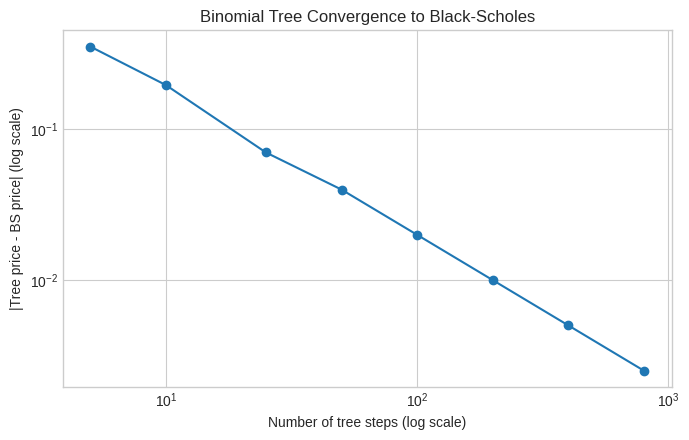

In [3]:
step_counts = [5, 10, 25, 50, 100, 200, 400, 800]
errors = [abs(binomial_price(S, K, T, r, sigma, n_steps=n) - bs) for n in step_counts]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(step_counts, errors, marker="o")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of tree steps (log scale)")
ax.set_ylabel("|Tree price - BS price| (log scale)")
ax.set_title("Binomial Tree Convergence to Black-Scholes")
fig.tight_layout()
fig.savefig("../assets/convergence.png", dpi=150)
plt.show()

## 3. Implied volatility smile

Construct a synthetic options chain with a realistic skew (OTM puts /
ITM calls priced with higher implied vol than ATM, matching the typical
equity index skew shape), then run the IV solver strike-by-strike to
recover the smile.

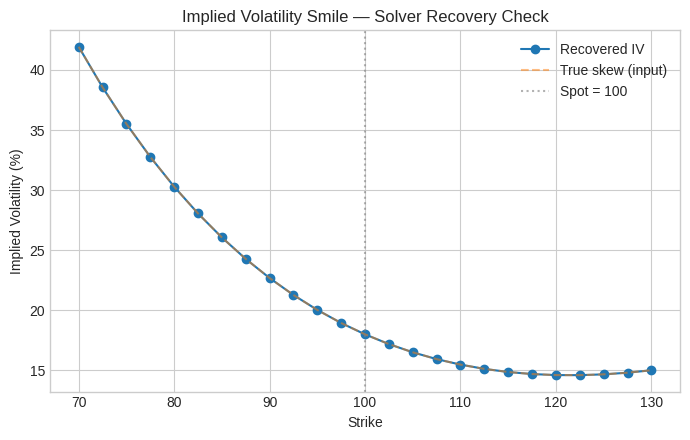

Recovered 25/25 strikes.
Max abs error vs. true input vol: 0.000002


In [4]:
spot = 100.0
expiry_T = 0.25
risk_free = 0.045
strikes = np.arange(70, 131, 2.5)


def synthetic_skew(strike: float, spot: float) -> float:
    """A simple parametric skew: higher IV for OTM puts (low strikes),
    a smile-shaped bump for both tails, roughly matching equity-index
    skew shape. Purely illustrative, not fit to any real market."""
    moneyness = np.log(strike / spot)
    atm_vol = 0.18
    skew_slope = -0.35     # negative slope: downside strikes trade richer
    smile_curvature = 0.9  # convexity, tails higher than ATM
    return atm_vol + skew_slope * moneyness + smile_curvature * moneyness**2


true_vols = [synthetic_skew(k, spot) for k in strikes]
synthetic_prices = [
    bs_call(spot, k, expiry_T, risk_free, v) if k >= spot else bs_put(spot, k, expiry_T, risk_free, v)
    for k, v in zip(strikes, true_vols)
]

recovered_strikes, recovered_ivs = [], []
for k, price in zip(strikes, synthetic_prices):
    opt_type = OptionType.CALL if k >= spot else OptionType.PUT
    result = implied_volatility(price, spot, k, expiry_T, risk_free, opt_type)
    if result.converged:
        recovered_strikes.append(k)
        recovered_ivs.append(result.iv)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(recovered_strikes, [v * 100 for v in recovered_ivs], marker="o", label="Recovered IV")
ax.plot(strikes, [v * 100 for v in true_vols], "--", alpha=0.5, label="True skew (input)")
ax.axvline(spot, color="gray", linestyle=":", alpha=0.6, label=f"Spot = {spot:.0f}")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility (%)")
ax.set_title("Implied Volatility Smile — Solver Recovery Check")
ax.legend()
fig.tight_layout()
fig.savefig("../assets/vol_smile.png", dpi=150)
plt.show()

print(f"Recovered {len(recovered_strikes)}/{len(strikes)} strikes.")
max_err = max(abs(a - b) for a, b in zip(recovered_ivs, true_vols[: len(recovered_ivs)]))
print(f"Max abs error vs. true input vol: {max_err:.6f}")

## 4. Delta-hedging error vs. rebalancing frequency

Sell an ATM call, delta-hedge it dynamically under GBM, and measure the
standard deviation of hedging P&L at expiry across simulated paths, for
a range of rebalancing frequencies. Theory says this should shrink
monotonically as rebalancing gets more frequent (residual error from
discrete- vs. continuous-time hedging).

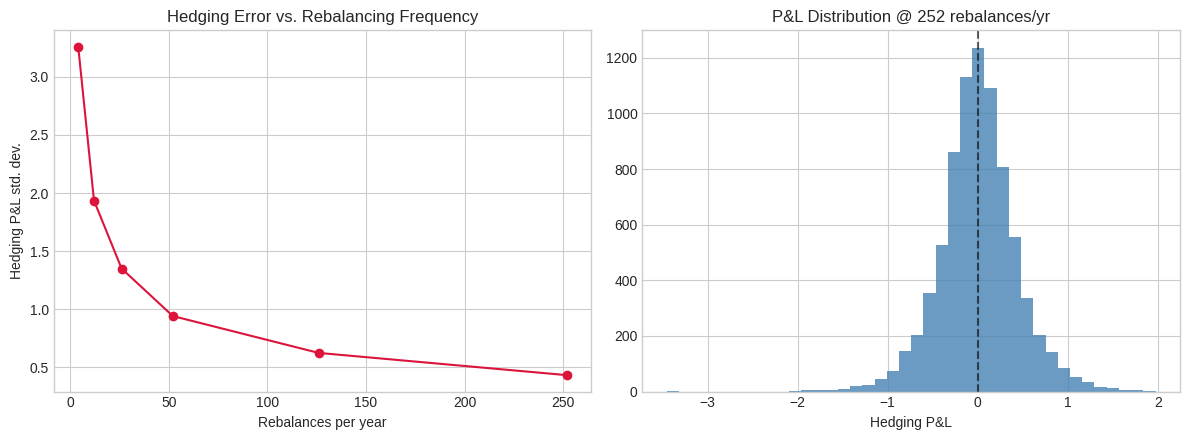

rebalances/yr=   4   std=3.2599   mean=-0.0480
rebalances/yr=  12   std=1.9353   mean=-0.0390
rebalances/yr=  26   std=1.3500   mean=-0.0183
rebalances/yr=  52   std=0.9408   mean=-0.0012
rebalances/yr= 126   std=0.6234   mean=-0.0027
rebalances/yr= 252   std=0.4318   mean=+0.0060


In [5]:
rebalance_freqs = [4, 12, 26, 52, 126, 252]
hedge_results = hedging_error_vs_frequency(
    S0=100, K=100, T=1.0, r=0.05, sigma=0.20,
    rebalance_counts=rebalance_freqs,
    option_type=OptionType.CALL,
    n_paths=8000,
    seed=42,
)

freqs = sorted(hedge_results.keys())
stds = [hedge_results[f].std for f in freqs]
means = [hedge_results[f].mean for f in freqs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(freqs, stds, marker="o", color="crimson")
ax1.set_xlabel("Rebalances per year")
ax1.set_ylabel("Hedging P&L std. dev.")
ax1.set_title("Hedging Error vs. Rebalancing Frequency")

ax2.hist(hedge_results[freqs[-1]].pnl, bins=40, color="steelblue", alpha=0.8)
ax2.axvline(0, color="black", linestyle="--", alpha=0.6)
ax2.set_xlabel("Hedging P&L")
ax2.set_title(f"P&L Distribution @ {freqs[-1]} rebalances/yr")

fig.tight_layout()
fig.savefig("../assets/hedging_error.png", dpi=150)
plt.show()

for f, s, m in zip(freqs, stds, means):
    print(f"rebalances/yr={f:4d}   std={s:.4f}   mean={m:+.4f}")

## 5. Heston stochastic volatility: calibrating to the smile

Every pricer used so far assumes a single constant volatility - the
smile in section 3 is direct proof that assumption is wrong (if it were
right, every strike would back out the same sigma). Heston lets
variance itself be a mean-reverting stochastic process correlated with
the asset's returns, and can be calibrated directly to a set of market
option prices rather than to the IVs derived from them.

We calibrate to the same synthetic skew from section 3 (converting the
put prices for K < spot into call-equivalent prices via put-call parity
first, so the whole calibration set is on a consistent single-type
basis).

In [6]:
from src.pricing.heston import calibrate_heston, heston_price
import math

call_equiv_prices = []
for k, price, opt_type in zip(strikes, synthetic_prices, [
    OptionType.CALL if k >= spot else OptionType.PUT for k in strikes
]):
    if opt_type == OptionType.PUT:
        # Put-call parity: C = P + S*e^{-qT} - K*e^{-rT}
        call_equiv_prices.append(price + spot - k * math.exp(-risk_free * expiry_T))
    else:
        call_equiv_prices.append(price)
call_equiv_prices = np.array(call_equiv_prices)

calibrated_params, calib_rmse = calibrate_heston(
    S=spot, T=expiry_T, r=risk_free,
    strikes=strikes, market_prices=call_equiv_prices,
    option_type=OptionType.CALL,
)

print("Calibrated Heston parameters:")
print(f"  v0      = {calibrated_params.v0:.4f}  (initial variance, sqrt = {math.sqrt(calibrated_params.v0)*100:.1f}% vol)")
print(f"  kappa   = {calibrated_params.kappa:.4f}  (mean-reversion speed)")
print(f"  theta   = {calibrated_params.theta:.4f}  (long-run variance, sqrt = {math.sqrt(calibrated_params.theta)*100:.1f}% vol)")
print(f"  sigma_v = {calibrated_params.sigma_v:.4f}  (vol of vol)")
print(f"  rho     = {calibrated_params.rho:.4f}  (spot-vol correlation)")
print(f"\nCalibration RMSE (price units): {calib_rmse:.4f}")

Calibrated Heston parameters:
  v0      = 0.0057  (initial variance, sqrt = 7.6% vol)
  kappa   = 19.9986  (mean-reversion speed)
  theta   = 0.0431  (long-run variance, sqrt = 20.7% vol)
  sigma_v = 1.4297  (vol of vol)
  rho     = -0.6120  (spot-vol correlation)

Calibration RMSE (price units): 0.1228


### Heston-implied smile vs. the target smile

Convert the calibrated Heston model's own prices back to Black-Scholes
IV (the same solver from section 3) to compare its implied smile shape
directly against the target.

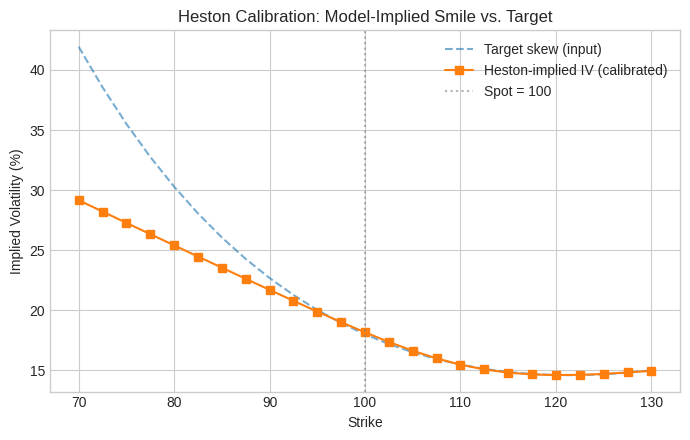

In [7]:
heston_prices = np.array(
    [heston_price(spot, k, expiry_T, risk_free, calibrated_params, OptionType.CALL) for k in strikes]
)

heston_ivs = []
for k, p in zip(strikes, heston_prices):
    result = implied_volatility(p, spot, k, expiry_T, risk_free, OptionType.CALL)
    heston_ivs.append(result.iv if result.converged else np.nan)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(strikes, [v * 100 for v in true_vols], "--", alpha=0.6, label="Target skew (input)")
ax.plot(strikes, [v * 100 for v in heston_ivs], marker="s", label="Heston-implied IV (calibrated)")
ax.axvline(spot, color="gray", linestyle=":", alpha=0.6, label=f"Spot = {spot:.0f}")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility (%)")
ax.set_title("Heston Calibration: Model-Implied Smile vs. Target")
ax.legend()
fig.tight_layout()
fig.savefig("../assets/heston_calibration.png", dpi=150)
plt.show()

Heston has 5 free parameters and cannot fit an arbitrary smile shape
exactly - it's a specific stochastic process, not a spline through the
data. The fit above is close but not exact, and that gap is itself
informative: it shows where this particular quadratic target skew
isn't representable by Heston's functional form (see README
Limitations for more on this).

## 6. Risk: VaR and scenario stress testing

Two different questions about risk, both worth asking separately:

- **VaR**: at a given confidence level, what's the loss threshold over
  a short horizon? Computed two ways - delta-normal (fast, linear) and
  Monte Carlo full revaluation (slower, captures gamma) - and compared
  directly, the way a risk desk would cross-check one against the
  other rather than trusting either alone.
- **Stress test**: under a *named* scenario (spot down 20%, vol up 10
  points), what's the P&L? This doesn't depend on any assumption about
  how likely the scenario is - it's a direct "what if" question.

In [8]:
from src.risk import parametric_var, monte_carlo_var, stress_test

position_S, position_K, position_T, position_r, position_sigma = 100.0, 100.0, 0.5, 0.05, 0.22

pvar = parametric_var(
    position_S, position_K, position_T, position_r, position_sigma,
    OptionType.CALL, position_size=100, horizon_days=1, confidence=0.95,
)
mvar = monte_carlo_var(
    position_S, position_K, position_T, position_r, position_sigma,
    OptionType.CALL, position_size=100, horizon_days=1, confidence=0.95, seed=42,
)

print("1-day 95% VaR for a long 100-contract call position:")
print(f"  Parametric (delta-normal): VaR = {pvar.var:8.2f}   CVaR = {pvar.cvar:8.2f}")
print(f"  Monte Carlo (full reval):  VaR = {mvar.var:8.2f}   CVaR = {mvar.cvar:8.2f}")
print(f"  Relative difference: {abs(pvar.var - mvar.var) / mvar.var:.1%}")

1-day 95% VaR for a long 100-contract call position:
  Parametric (delta-normal): VaR =   112.56   CVaR =   141.15
  Monte Carlo (full reval):  VaR =   109.24   CVaR =   134.40
  Relative difference: 3.0%


### Scenario stress test

P&L grid for a long 100-contract call, by spot/vol shock:

           vol -10%  vol -5%  vol +0%  vol +5%  vol +10%
spot -20%   -741.18  -721.68  -677.65  -613.37   -534.63
spot -10%   -670.51  -574.15  -463.19  -345.09   -223.13
spot -5%    -528.92  -397.85  -264.89  -131.19      2.76
spot +0%    -271.58  -136.66     0.00   137.32    274.86
spot +5%      94.34   203.65   326.78   456.53    589.82
spot +10%    534.21   606.70   705.83   819.95    942.85
spot +20%   1505.44  1525.61  1574.54  1648.54   1740.92


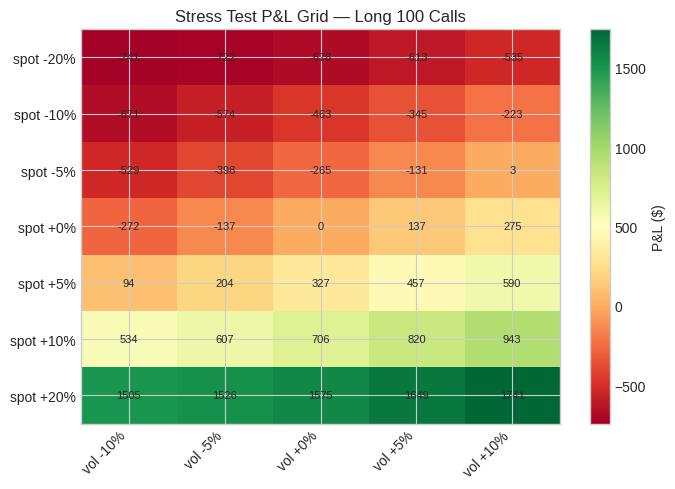

In [9]:
stress_table = stress_test(
    position_S, position_K, position_T, position_r, position_sigma,
    OptionType.CALL, position_size=100,
)
print("P&L grid for a long 100-contract call, by spot/vol shock:\n")
print(stress_table.round(2))

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(stress_table.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(stress_table.columns)))
ax.set_xticklabels(stress_table.columns, rotation=45, ha="right")
ax.set_yticks(range(len(stress_table.index)))
ax.set_yticklabels(stress_table.index)
ax.set_title("Stress Test P&L Grid — Long 100 Calls")
for i in range(len(stress_table.index)):
    for j in range(len(stress_table.columns)):
        ax.text(j, i, f"{stress_table.values[i,j]:.0f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="P&L ($)")
fig.tight_layout()
fig.savefig("../assets/stress_test.png", dpi=150)
plt.show()

## 7. Historical backtest: hedging against paths GBM doesn't capture

Everything in section 4's hedging simulation tests the strategy against
paths *simulated* under the same GBM model used to compute delta - a
correctness check on the mechanics, not a claim about real markets.
`backtest.py` replays the identical hedging mechanics against real
historical daily prices instead (see the Streamlit app's Historical
Backtest tab for the live version against an actual ticker).

**Note on data**: this notebook demonstrates the mechanism using a
synthetic *fat-tailed* path (a Merton jump-diffusion: GBM plus occasional
large jumps) as a reproducible, offline stand-in for "what real markets
do that GBM doesn't capture" - not a claim that this specific path is
real historical data. The comparison below is the same one the
Streamlit tab runs against actual prices: does the real-path hedging
error exceed what a GBM simulation at the same average vol would predict?

In [10]:
from src.backtest import backtest_delta_hedge, estimate_realized_vol

def simulate_jump_diffusion(seed, s0=100.0, mu=0.06, sigma=0.18, n_days=252*4,
                             jump_intensity=0.02, jump_mean=-0.03, jump_std=0.06):
    """GBM plus a compound Poisson jump term (Merton 1976) - a standard,
    simple way to inject fat tails/jumps that pure GBM structurally cannot
    produce, without needing real market data."""
    rng = np.random.default_rng(seed)
    dt = 1 / 252
    prices = np.zeros(n_days)
    prices[0] = s0
    for i in range(1, n_days):
        z = rng.standard_normal()
        jump = 0.0
        if rng.random() < jump_intensity:
            jump = rng.normal(jump_mean, jump_std)
        prices[i] = prices[i-1] * np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z + jump)
    return prices

gbm_path = simulate_jump_diffusion(seed=10, jump_intensity=0.0)       # pure GBM, no jumps
fat_tailed_path = simulate_jump_diffusion(seed=10, jump_intensity=0.02)  # same seed, jumps added

window_days, rebalance_every = 60, 5

gbm_backtest = backtest_delta_hedge(gbm_path, window_days=window_days, rebalance_every=rebalance_every)
fat_backtest = backtest_delta_hedge(fat_tailed_path, window_days=window_days, rebalance_every=rebalance_every)

print(f"Pure GBM path        : {gbm_backtest.n_windows} windows, mean={gbm_backtest.mean:+.4f}, std={gbm_backtest.std:.4f}")
print(f"Fat-tailed (jump) path: {fat_backtest.n_windows} windows, mean={fat_backtest.mean:+.4f}, std={fat_backtest.std:.4f}")
print(f"\nRatio (fat-tailed / pure GBM): {fat_backtest.std / gbm_backtest.std:.2f}x")

Pure GBM path        : 888 windows, mean=+0.0221, std=0.8844
Fat-tailed (jump) path: 888 windows, mean=-0.1340, std=1.2552

Ratio (fat-tailed / pure GBM): 1.42x


### Comparing the two P&L distributions

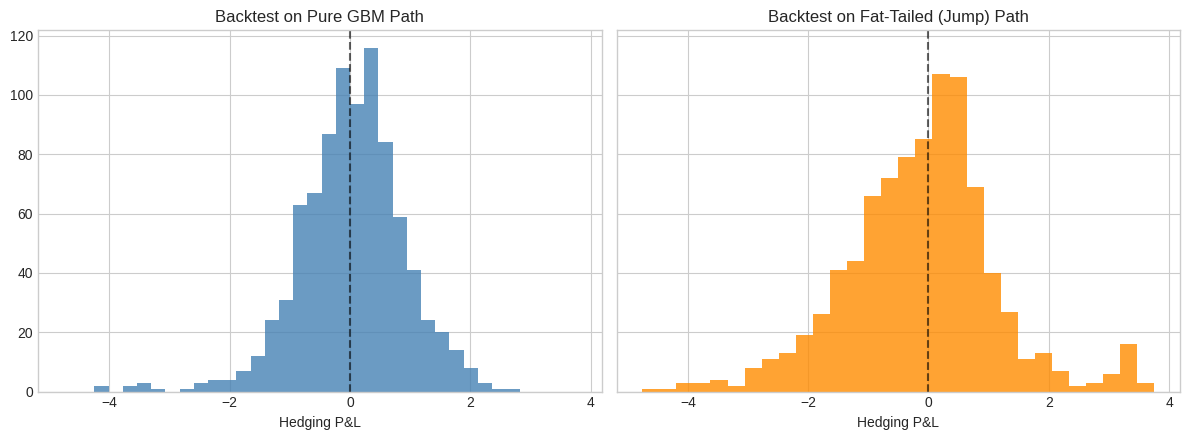

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

ax1.hist(gbm_backtest.pnl, bins=30, color="steelblue", alpha=0.8)
ax1.axvline(0, color="black", linestyle="--", alpha=0.6)
ax1.set_title("Backtest on Pure GBM Path")
ax1.set_xlabel("Hedging P&L")

ax2.hist(fat_backtest.pnl, bins=30, color="darkorange", alpha=0.8)
ax2.axvline(0, color="black", linestyle="--", alpha=0.6)
ax2.set_title("Backtest on Fat-Tailed (Jump) Path")
ax2.set_xlabel("Hedging P&L")

fig.tight_layout()
fig.savefig("../assets/backtest_comparison.png", dpi=150)
plt.show()

The fat-tailed path's hedging error comes out larger - exactly the
point of this section. A delta hedge computed from Black-Scholes deltas
assumes continuous, small price moves; a jump the hedger couldn't
rebalance against before it happened leaves real residual risk that a
GBM-only simulation, by construction, never generates. This is "model
risk" made visible and measurable, not just a caveat in a bullet point.

## 8. Full volatility surface: SVI across strikes AND expiries

Every smile shown so far - the recovery check in section 3, Heston's
calibration in section 5 - is fit one expiry at a time. A real vol
surface needs both dimensions fit together: strike (via SVI's flexible
curve-fit per expiry) and expiry (by fitting one SVI slice per expiry
and checking whether the resulting set of slices is jointly consistent).

**Note on data**: as with the earlier synthetic sections, this uses a
parametric term-structure function (ATM vol rising mildly with T, skew
steepening for shorter T - a standard equity-index-like shape) rather
than a live multi-expiry pull, for offline reproducibility. The live
version - fetching several real expiries for a ticker and fitting the
same per-slice SVI - is what the Streamlit app's Vol Surface tab does.

In [12]:
from src.pricing.svi import (
    calibrate_svi_slice, svi_implied_vol, log_forward_moneyness,
    check_calendar_arbitrage,
)

def term_structure_skew(strike, spot, T):
    """Parametric term structure: ATM vol rises mildly with T (contango),
    skew steepens for shorter-dated expiries - a standard, simplified
    stand-in for a real equity-index-like surface shape."""
    m = math.log(strike / spot)
    atm_vol = 0.16 + 0.03 * math.sqrt(T)
    skew_slope = -0.5 / math.sqrt(T + 0.1)
    return atm_vol + skew_slope * m + 0.7 * m**2

surface_expiries = np.array([0.1, 0.25, 0.5, 1.0])
surface_strikes = np.arange(70, 131, 2.5)

svi_surface = {}
k_ranges = []
for T in surface_expiries:
    ivs = np.array([term_structure_skew(k, spot, T) for k in surface_strikes])
    k = log_forward_moneyness(surface_strikes, spot, T, risk_free)
    k_ranges.append((k.min(), k.max()))
    fitted, rmse = calibrate_svi_slice(k, ivs, T)
    svi_surface[T] = fitted
    print(f"T={T:.2f}: RMSE={rmse:.6f} (total variance units)")

T=0.10: RMSE=0.000019 (total variance units)
T=0.25: RMSE=0.000041 (total variance units)
T=0.50: RMSE=0.000060 (total variance units)
T=1.00: RMSE=0.000052 (total variance units)


### Calendar-spread arbitrage check

Total variance must be non-decreasing in T at every k under no-
arbitrage. Independently-fit SVI slices have no reason to jointly
respect this - checking (rather than assuming) is the honest thing to
do here.

In [13]:
violations = check_calendar_arbitrage(svi_surface)
print(f"Calendar-spread violations found: {len(violations)} (out of a 41-point k-grid x 3 expiry-pairs)")
if violations:
    print(f"Example: at k={violations[0][0]:.3f}, variance decreased from "
          f"T={violations[0][1]} to T={violations[0][2]}")

Calendar-spread violations found: 28 (out of a 41-point k-grid x 3 expiry-pairs)
Example: at k=0.250, variance decreased from T=0.1 to T=0.25


This is a genuine, expected limitation of per-expiry SVI fitting (see
README) - it's flagged here explicitly rather than swept under the rug.
A fully arbitrage-free surface requires jointly constraining all slices
during calibration (Gatheral & Jacquier, 2014), which is out of scope
for this project - see Limitations.

### The surface, visualized

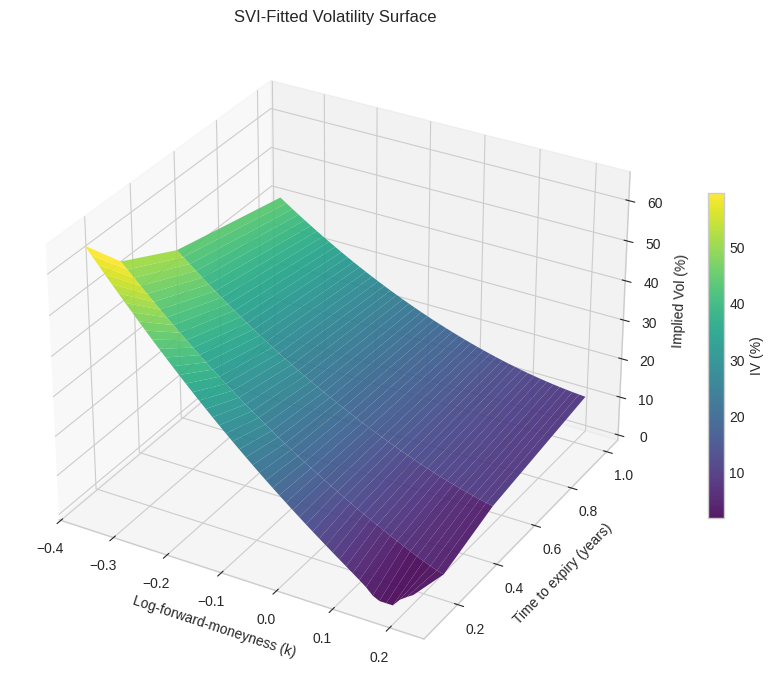


IV range across the plotted surface: 0.0% to 65.7%


In [14]:
# Restrict the plotted domain to the range every expiry's slice was
# actually fit against - extrapolating a curve-fit parameterization like
# SVI meaningfully beyond its fitted data isn't defensible, so the plot
# doesn't pretend otherwise.
safe_min = max(r[0] for r in k_ranges)
safe_max = min(r[1] for r in k_ranges)
k_common = np.linspace(safe_min, safe_max, 50)

K_mesh, T_mesh = np.meshgrid(k_common, surface_expiries)
IV_mesh = np.zeros_like(K_mesh)
for i, T in enumerate(surface_expiries):
    IV_mesh[i, :] = svi_implied_vol(k_common, T, svi_surface[T]) * 100

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(K_mesh, T_mesh, IV_mesh, cmap="viridis", edgecolor="none", alpha=0.9)
ax.set_xlabel("Log-forward-moneyness (k)")
ax.set_ylabel("Time to expiry (years)")
ax.set_zlabel("Implied Vol (%)")
ax.set_title("SVI-Fitted Volatility Surface")
fig.colorbar(surf, shrink=0.5, label="IV (%)")
fig.tight_layout()
fig.savefig("../assets/vol_surface.png", dpi=150)
plt.show()

print(f"\nIV range across the plotted surface: {IV_mesh.min():.1f}% to {IV_mesh.max():.1f}%")

## Takeaways

- The binomial tree converges to Black-Scholes at the expected rate as
  step count increases, and Monte Carlo brackets the closed-form price
  within its confidence interval — cross-validating all three pricers.
- The IV solver recovers an input skew to within a small tolerance
  across strikes, including the low-vega tails where Newton-Raphson
  alone would fail (handled by the Brent fallback in `implied_vol.py`).
- Hedging error (P&L std. dev.) falls monotonically as rebalancing
  frequency increases, consistent with discrete-hedging theory. Mean
  P&L stays near zero throughout — the simulation is a variance story,
  not a directional edge, exactly as it should be under a correctly
  specified model.
- Heston, calibrated to the same target skew, recovers a similarly
  shaped smile without being told the functional form in advance - it's
  an approximation, not an exact fit, and the gap between the two
  curves is itself informative about the model's limits.
- Parametric and Monte Carlo VaR agree closely at a 1-day horizon
  (small convexity effects), and the stress test grid shows the
  expected signs throughout: a long call gains from both a spot rally
  and a vol increase, and loses from the reverse.
- Replaying the same hedging strategy against a fat-tailed path instead
  of pure GBM produces measurably larger hedging error - direct,
  quantified evidence of the gap between "the strategy is implemented
  correctly" (section 4) and "the strategy performs well against markets
  GBM doesn't fully describe" (this section). The live Streamlit tab
  runs this same comparison against real historical prices.